In [ ]:
import torch 
import torch.optim as optim 
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torchvision import transforms, models, datasets 

In [5]:
train_40X = "Final-40X\\train" 
val_40X = "Final-40X\\val"

train_100X = "Final-100X\\train" 
val_100X = "Final-100X\\val"

train_200X = "Final-200X\\train"
val_200X = "Final-200X\\val" 

train_400X = "Final-400X\\train"
val_400X = "Final-400X\\val" 

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [7]:
model = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
device = torch.device("cuda")


# Training on 40X Dataset without preprocessing

In [ ]:
train_data = datasets.ImageFolder(train_40X, transform=transform)
val_data   = datasets.ImageFolder(val_40X, transform=transform)


In [10]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)


In [11]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 1),  
)

In [13]:
model = model.to(device)

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_model(model, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                outputs = torch.sigmoid(model(imgs))
                preds.extend((outputs.cpu().numpy() > 0.5).astype(int))
                true.extend(labels.numpy())

        acc = accuracy_score(true, preds)
        f1  = f1_score(true, preds)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")



In [21]:
train_model(model, epochs=15)

Epoch 1/15 | Loss: 0.6697 | Acc: 0.7122 | F1: 0.7457
Epoch 2/15 | Loss: 0.5826 | Acc: 0.8098 | F1: 0.8251
Epoch 3/15 | Loss: 0.5209 | Acc: 0.8683 | F1: 0.8720
Epoch 4/15 | Loss: 0.4730 | Acc: 0.8878 | F1: 0.8930
Epoch 5/15 | Loss: 0.4345 | Acc: 0.8878 | F1: 0.8915
Epoch 6/15 | Loss: 0.4111 | Acc: 0.9024 | F1: 0.9078
Epoch 7/15 | Loss: 0.3877 | Acc: 0.9000 | F1: 0.9017
Epoch 8/15 | Loss: 0.3699 | Acc: 0.9024 | F1: 0.9065
Epoch 9/15 | Loss: 0.3506 | Acc: 0.9098 | F1: 0.9125
Epoch 10/15 | Loss: 0.3403 | Acc: 0.9098 | F1: 0.9142
Epoch 11/15 | Loss: 0.3279 | Acc: 0.9073 | F1: 0.9112
Epoch 12/15 | Loss: 0.3181 | Acc: 0.9024 | F1: 0.9065
Epoch 13/15 | Loss: 0.3073 | Acc: 0.9171 | F1: 0.9190
Epoch 14/15 | Loss: 0.2985 | Acc: 0.9220 | F1: 0.9242
Epoch 15/15 | Loss: 0.2923 | Acc: 0.9195 | F1: 0.9231


In [22]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)


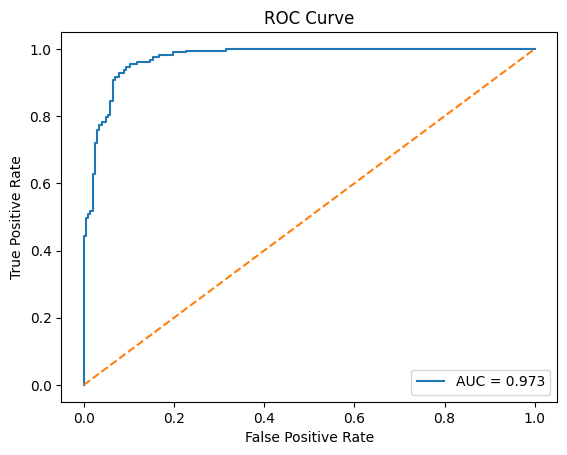

In [23]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


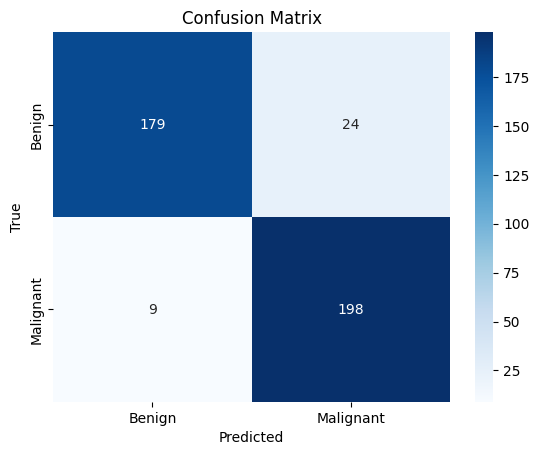

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [25]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.88      0.92       203
   Malignant       0.89      0.96      0.92       207

    accuracy                           0.92       410
   macro avg       0.92      0.92      0.92       410
weighted avg       0.92      0.92      0.92       410



In [26]:
torch.save(model.state_dict(), "Densenet40X.pth")
print("Model saved as Densenet40X.pth")


Model saved as Densenet40X.pth


# Training on 100X Dataset without preprocessing

In [30]:
train_data2 = datasets.ImageFolder(train_100X, transform=transform)
val_data2  = datasets.ImageFolder(val_100X, transform=transform)


In [31]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


In [32]:
for param in model.features.parameters():
    param.requires_grad = False

In [34]:
fresh_model = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
fresh_model = model.to(device)

In [38]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [39]:
train_model(fresh_model, epochs=15)

Epoch 1/15 | Loss: 0.3130 | Acc: 0.9097 | F1: 0.9128
Epoch 2/15 | Loss: 0.3138 | Acc: 0.9169 | F1: 0.9195
Epoch 3/15 | Loss: 0.3022 | Acc: 0.9240 | F1: 0.9286
Epoch 4/15 | Loss: 0.2905 | Acc: 0.9287 | F1: 0.9312
Epoch 5/15 | Loss: 0.2828 | Acc: 0.9264 | F1: 0.9310
Epoch 6/15 | Loss: 0.2835 | Acc: 0.9335 | F1: 0.9364
Epoch 7/15 | Loss: 0.2770 | Acc: 0.9359 | F1: 0.9374
Epoch 8/15 | Loss: 0.2722 | Acc: 0.9382 | F1: 0.9406
Epoch 9/15 | Loss: 0.2629 | Acc: 0.9311 | F1: 0.9339
Epoch 10/15 | Loss: 0.2565 | Acc: 0.9454 | F1: 0.9474
Epoch 11/15 | Loss: 0.2587 | Acc: 0.9335 | F1: 0.9349
Epoch 12/15 | Loss: 0.2506 | Acc: 0.9382 | F1: 0.9401
Epoch 13/15 | Loss: 0.2457 | Acc: 0.9406 | F1: 0.9425
Epoch 14/15 | Loss: 0.2445 | Acc: 0.9430 | F1: 0.9444
Epoch 15/15 | Loss: 0.2412 | Acc: 0.9406 | F1: 0.9425


In [50]:
torch.save(fresh_model.state_dict(), "Densenet100X.pth")
print("Model saved as Densenet100X.pth")

Model saved as Densenet100X.pth


In [40]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)


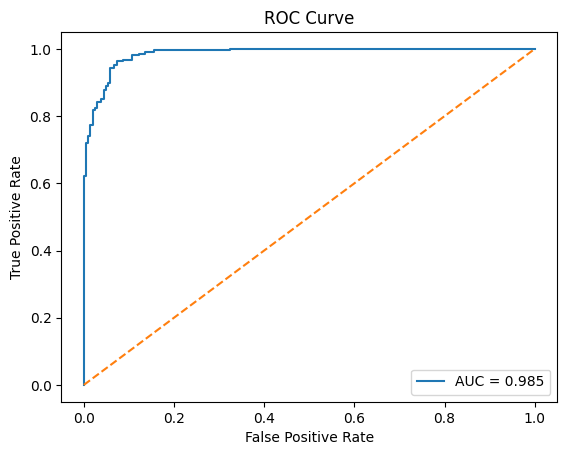

In [41]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


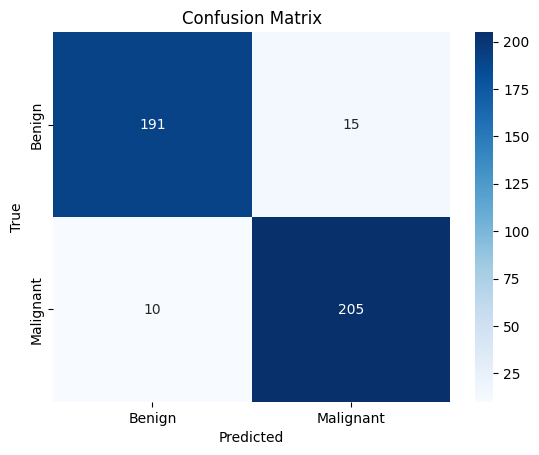

In [42]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [43]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.93      0.94       206
   Malignant       0.93      0.95      0.94       215

    accuracy                           0.94       421
   macro avg       0.94      0.94      0.94       421
weighted avg       0.94      0.94      0.94       421



# Training on 200X Dataset

In [44]:
train_data3 = datasets.ImageFolder(train_200X, transform=transform)
val_data3  = datasets.ImageFolder(val_200X, transform=transform)


In [45]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


In [46]:
for param in model.features.parameters():
    param.requires_grad = False

In [47]:
fresh_model2 = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [48]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [49]:
train_model(fresh_model, epochs=15)

Epoch 1/15 | Loss: 0.2372 | Acc: 0.9430 | F1: 0.9452
Epoch 2/15 | Loss: 0.2299 | Acc: 0.9454 | F1: 0.9471
Epoch 3/15 | Loss: 0.2323 | Acc: 0.9430 | F1: 0.9450
Epoch 4/15 | Loss: 0.2294 | Acc: 0.9430 | F1: 0.9450
Epoch 5/15 | Loss: 0.2229 | Acc: 0.9454 | F1: 0.9476
Epoch 6/15 | Loss: 0.2309 | Acc: 0.9454 | F1: 0.9471
Epoch 7/15 | Loss: 0.2174 | Acc: 0.9430 | F1: 0.9452
Epoch 8/15 | Loss: 0.2161 | Acc: 0.9454 | F1: 0.9474
Epoch 9/15 | Loss: 0.2141 | Acc: 0.9406 | F1: 0.9420
Epoch 10/15 | Loss: 0.2172 | Acc: 0.9477 | F1: 0.9495
Epoch 11/15 | Loss: 0.2201 | Acc: 0.9406 | F1: 0.9423
Epoch 12/15 | Loss: 0.2098 | Acc: 0.9430 | F1: 0.9444
Epoch 13/15 | Loss: 0.2111 | Acc: 0.9454 | F1: 0.9471
Epoch 14/15 | Loss: 0.2100 | Acc: 0.9477 | F1: 0.9495
Epoch 15/15 | Loss: 0.2065 | Acc: 0.9477 | F1: 0.9488


In [51]:
torch.save(fresh_model2.state_dict(), "Densenet200X.pth")
print("Model saved as Densenet200X.pth")

Model saved as Densenet200X.pth


In [52]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.extend(outputs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)



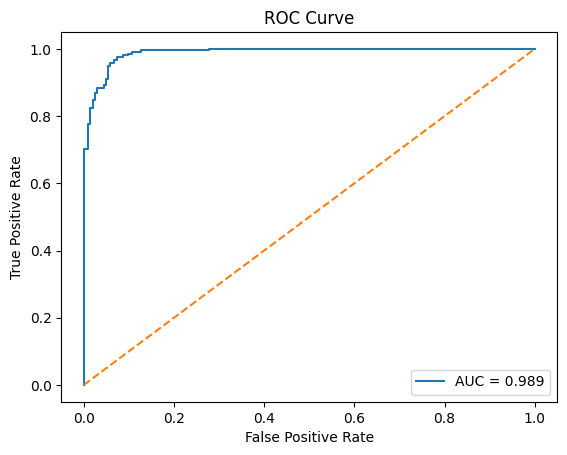

In [53]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


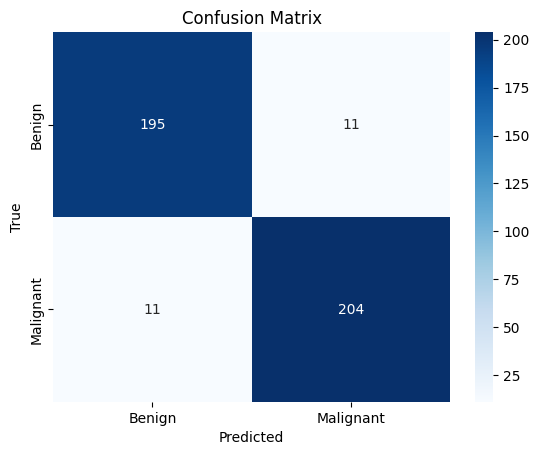

In [54]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [55]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))


Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.95      0.95       206
   Malignant       0.95      0.95      0.95       215

    accuracy                           0.95       421
   macro avg       0.95      0.95      0.95       421
weighted avg       0.95      0.95      0.95       421



# Training on 400X Dataset

In [56]:
train_data4 = datasets.ImageFolder(train_400X, transform=transform)
val_data4  = datasets.ImageFolder(val_400X, transform=transform)


In [57]:
train_loader = DataLoader(train_data2, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data2, batch_size=32, shuffle=False)


In [58]:
for param in model.features.parameters():
    param.requires_grad = False

In [59]:
fresh_model3 = models.densenet121(pretrained=True)

c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [60]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
train_model(fresh_model, epochs=15)

Epoch 1/15 | Loss: 0.2048 | Acc: 0.9454 | F1: 0.9469
